# Results Analysis

This notebook loads the outputs of `main.py` and visualizes/interprets the walk-forward comparison between
the Naive baseline (sanity floor, the null hypothesis), GARCH(1,1) (the classical baseline model), XGBoost (the ML model), and LSTM (the DL model).

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

RESULTS_DIR = os.path.join('..', 'results')

results = pd.read_csv(os.path.join(RESULTS_DIR, 'results.csv'), index_col=0)
forecasts = pd.read_csv(os.path.join(RESULTS_DIR, 'forecasts.csv'))
colors = ['#5B82AD','#D0A52A', '#2A958E', '#966BB5', '#B85C5C', '#7A7A7A', '#333333']

## 1. Model Comparison 

To compare the models we use the following metrics:
- **RMSE**: Standard error metric, sensitive to noise in the realized-vol proxy.
- **QLIKE**: The standard loss function in the academic volatility literature, more robust to proxy noise than RMSE.
- **Directional Accuracy**: Did the model correctly call whether volatility would rise or fall?

In [2]:
print('Loaded results for models:', list(results.index))
results

Loaded results for models: ['Naive', 'GARCH', 'XGBoost', 'LSTM']


,RMSE,QLIKE,DirectionalAccuracy
Naive,0.106458,0.220172,0.000000
GARCH,0.098008,0.134386,0.643056
XGBoost,0.095197,0.126316,0.690741
LSTM,0.126950,0.227186,0.591204


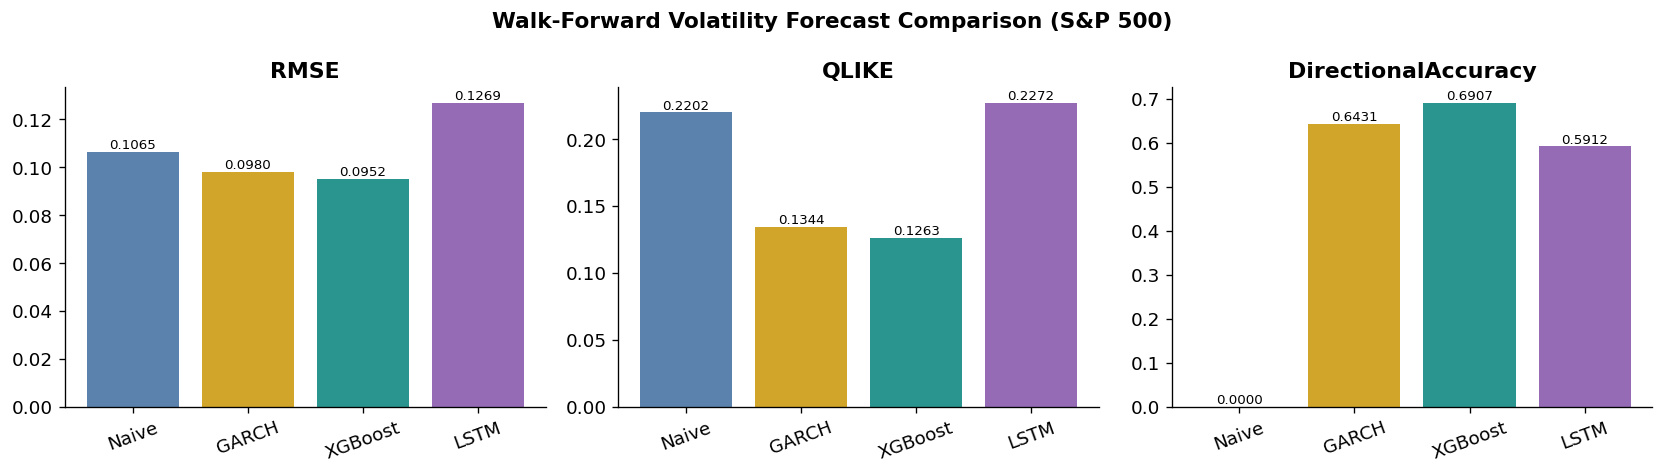

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['RMSE', 'QLIKE', 'DirectionalAccuracy']
for ax, metric in zip(axes, metrics):
    vals = results[metric].astype(float)
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Walk-Forward Volatility Forecast Comparison (S&P 500)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [4]:
best_rmse = results['RMSE'].astype(float).idxmin()
best_qlike = results['QLIKE'].astype(float).idxmin()
best_dir = results['DirectionalAccuracy'].astype(float).idxmax()

print(f"Best by RMSE               : {best_rmse}")
print(f"Best by QLIKE               : {best_qlike}")
print(f"Best by Directional Accuracy: {best_dir}")
print()

beats_naive = results['RMSE'].astype(float).drop('Naive', errors='ignore') < results.loc['Naive', 'RMSE']

Best by RMSE               : XGBoost
Best by QLIKE               : XGBoost
Best by Directional Accuracy: XGBoost



## 2. Forecast vs. Actual Best Model

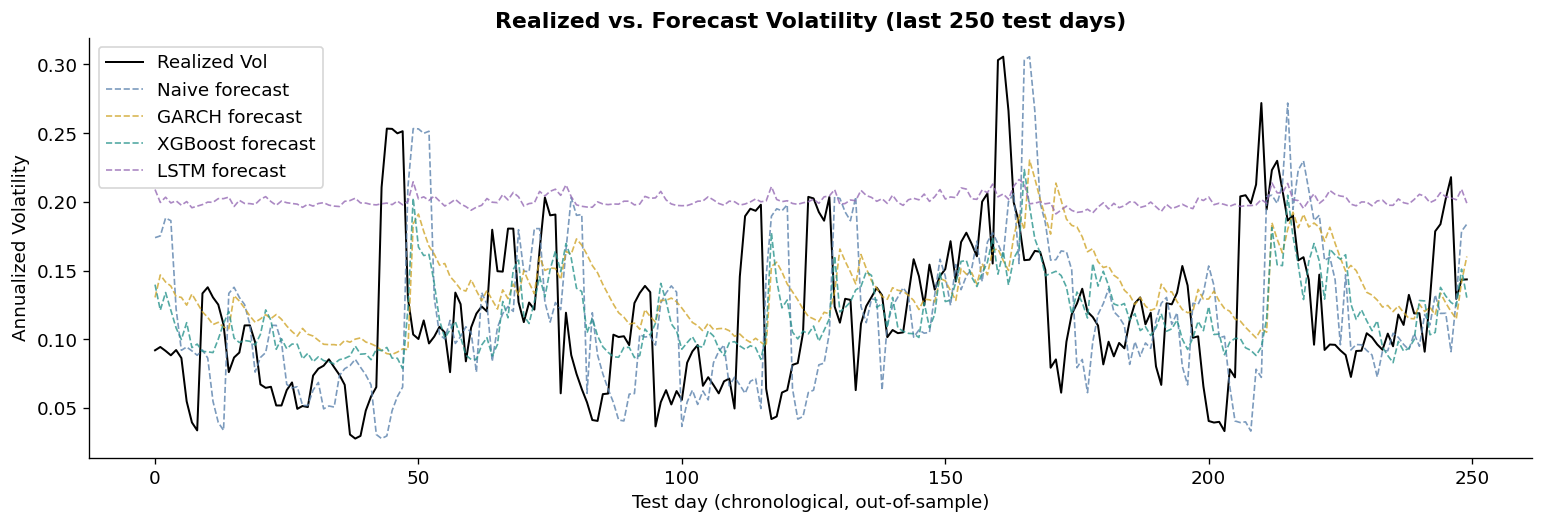

In [5]:
n = min(len(forecasts), 250)
recent = forecasts.tail(n)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(recent['actual'].values, label='Realized Vol', color='black', linewidth=1.2)

for model, color in zip(['Naive', 'GARCH', 'XGBoost', 'LSTM'], colors):
    if model in recent.columns:
        ax.plot(recent[model].values, label=f'{model} forecast',
                linewidth=1, linestyle='--', alpha=0.8, color=color)

ax.set_title(f'Realized vs. Forecast Volatility (last {n} test days)', fontweight='bold')
ax.set_ylabel('Annualized Volatility')
ax.set_xlabel('Test day (chronological, out-of-sample)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'forecast_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Error Analysis

Plotting forecast errors over time to reveal whether errors cluster around
specific regimes (e.g. crisis periods, regime transitions) rather than being
uniformly distributed.

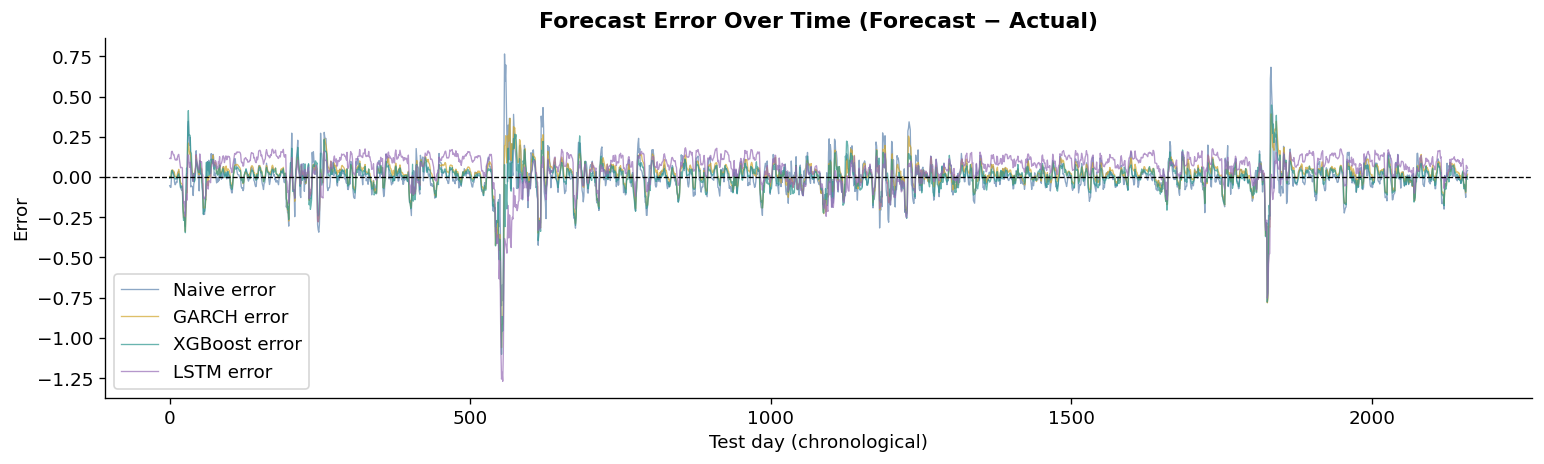

In [6]:
model_cols = [c for c in ['Naive', 'GARCH', 'XGBoost', 'LSTM'] if c in forecasts.columns]

fig, ax = plt.subplots(figsize=(13, 4))
for model, color in zip(model_cols, colors):
    error = forecasts[model] - forecasts['actual']
    ax.plot(error.values, label=f'{model} error', alpha=0.7, linewidth=0.8, color=color)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Forecast Error Over Time (Forecast − Actual)', fontweight='bold')
ax.set_ylabel('Error')
ax.set_xlabel('Test day (chronological)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Error Distribution by Model

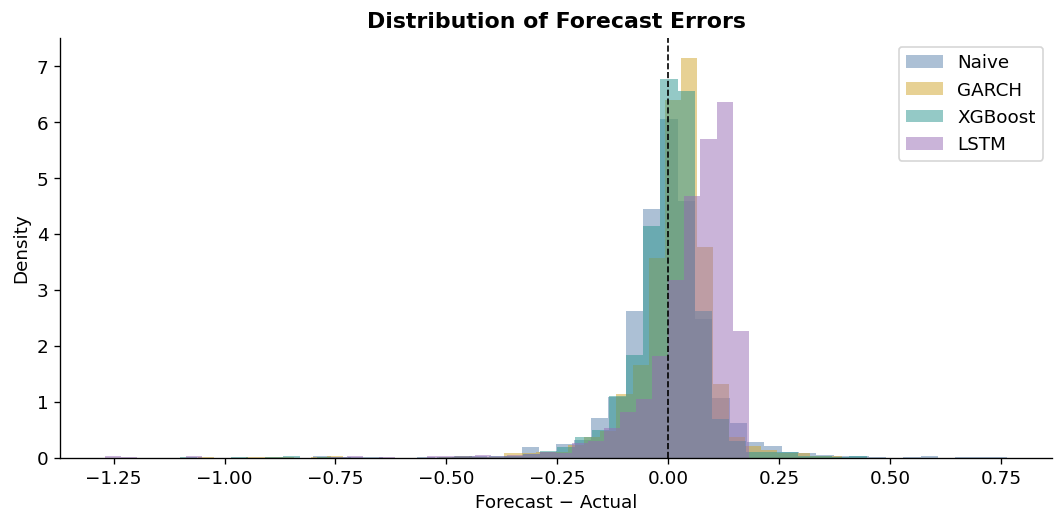

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for model, color in zip(model_cols, colors):
    error = forecasts[model] - forecasts['actual']
    ax.hist(error, bins=40, alpha=0.5, label=model, color=color, density=True)

ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Distribution of Forecast Errors', fontweight='bold')
ax.set_xlabel('Forecast − Actual')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## 5. XGBoost Feature Importance

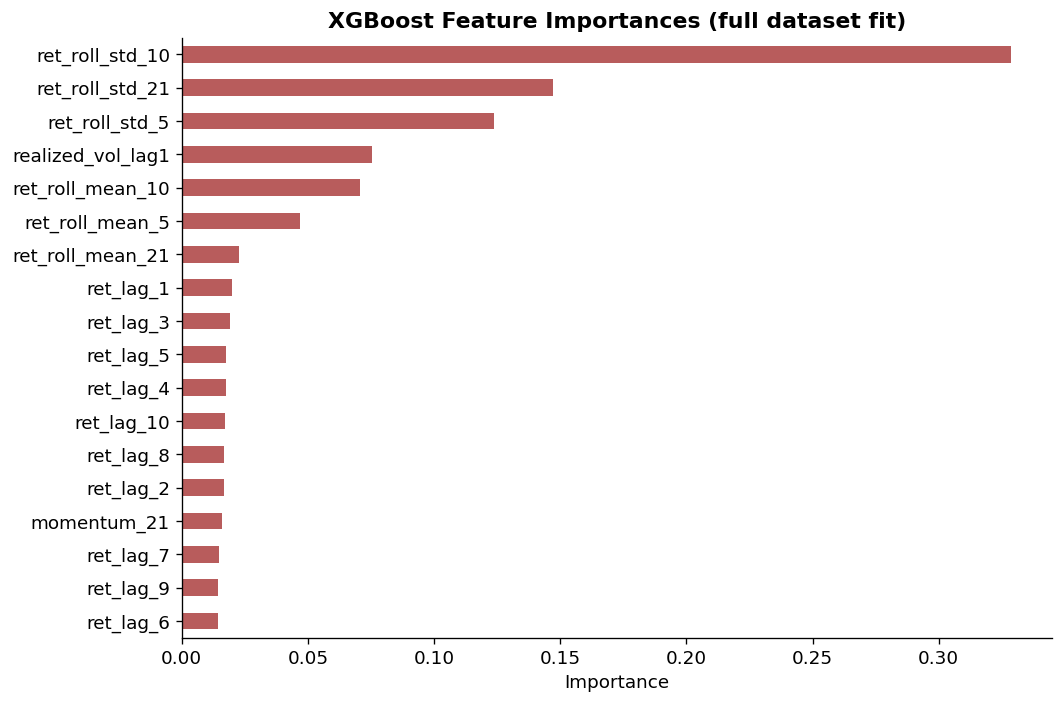

Top 5 features:
ret_roll_std_10      0.328592
ret_roll_std_21      0.147112
ret_roll_std_5       0.123833
realized_vol_lag1    0.075243
ret_roll_mean_10     0.070598
dtype: float32


In [8]:
# Re-fit XGBoost on the full dataset just for feature-importance inspection
# (not for the walk-forward results themselves, which are in results.csv)
from data_loader import load_dataset
from features import build_feature_matrix, get_feature_names, TARGET_COL
from models.ml_xgboost import XGBVolModel

raw = load_dataset(vol_window=5)
feature_df = build_feature_matrix(raw).dropna(subset=[TARGET_COL])
feature_cols = get_feature_names(feature_df)

model = XGBVolModel().fit(feature_df[feature_cols], feature_df[TARGET_COL])
importances = model.feature_importances(feature_cols)

fig, ax = plt.subplots(figsize=(9, 6))
importances.sort_values().plot(kind='barh', ax=ax, color=colors[-3])
ax.set_title('XGBoost Feature Importances (full dataset fit)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.head())

## 6. Conclusions

- **XGBoost achieved the best point-forecast accuracy** (lowest RMSE and QLIKE) 
  and the best directional accuracy of all models tested.
- **GARCH outperformed the naive persistence baseline on every metric**, 
  confirming the classical model is capturing real structure in the data 
  before being compared against ML/DL approaches.
- **LSTM underperformed both GARCH and XGBoost** on point-forecast accuracy. This is consistent 
  with the general finding that deep learning models typically need 
  substantially more data than a single ~20-year daily series (~5,400 
  observations) provides to reliably outperform well-specified classical 
  and tree-based methods.
- **XGBoost's top features** were dominated by rolling standard deviations 
  of returns (`ret_roll_std_10`, `ret_roll_std_21`, `ret_roll_std_5`), 
  followed by `realized_vol_lag1` and `ret_roll_mean_10`. This is consistent 
  with volatility clustering: recent return dispersion across multiple 
  trailing windows is more informative than any single lagged volatility 
  estimate alone. Effectively, the model is learning its own multi-scale 
  view of "how turbulent has it been lately."
- **Future steps**: Extend to a cross-sectional universe of 
  assets to test whether XGBoost's advantage generalizes beyond a single 
  index, and run a Diebold-Mariano test to confirm XGBoost's improvement 
  over GARCH is statistically significant rather than noise in this 
  particular sample.